<a href="https://colab.research.google.com/github/jotaeleb/tif-ciencias-de-datos/blob/main/notebooks/proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️🔍TIF Análisis de Detección de Intrusiones en Red


# 1. Comprensión del negocio

### Contexto

En el actual panorama de amenazas digitales, la identificación rápida y precisa de actividades maliciosas es crítica para la infraestructura de red. Este proyecto aborda este desafío mediante el desarrollo de un Sistema de Detección de Intrusiones (IDS) basado en inteligencia artificial. El objetivo principal es clasificar el tráfico de red entre comportamientos benignos y diversos tipos de ataques cibernéticos con el fin de minimizar los falsos negativos y garantizar la integridad del sistema.

### Dataset

El dataset fue diseñado por el Canadian Institute for Cybersecurity (CIC) para el desarrollo y evaluación de sistemas de detección de intrusiones. Contiene más de 2,8 millones de instancias capturadas durante 5 días, incluyendo tráfico normal y ataques como Brute Force, Heartbleed, Botnet, DoS, DDoS, Web Attack e Infiltración. Tiene 79 columnas con 78 features numéricas y una columna categórica de etiqueta (Label).

Fuentes: [UNB - CIC-IDS-2017](https://www.unb.ca/cic/datasets/ids-2017.html)
[kaggle](https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset)

## 1.1 Definición del Problema

**Problema**: Clasificar tráfico de red como benigno vs malicioso y eventualmente por tipo de ataque.

**Tipo de problema**: Clasificación supervisada

**Objetivo**:
* Detectar intrusiones con alta precisión y recall
* Minimizar falsos negativos (ataques no detectados)

## 1.2 Fichas del proyecto

[📋 Información del dataset](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/ficha_del_proyecto.md)

[📖 Diccionario de Datos](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/diccionario_de_datos.md)

[🛡️ Diccionario de Clases y Tipos de Ataques](https://github.com/jotaeleb/tif-ciencias-de-datos/blob/main/resources/clase_label.md)

## 1.3 ⚠️ Problemas del dataset

* **Tamaño del archivo**: 2,8M de filas puede ser lento en máquinas locales. Nosotros vamos a trabajar con archivos .parquet ya que optimiza el almacenamiento mediante una estructura columnar que maximiza la compresión y acelera las consultas al leer solo los datos necesarios.

* **Valores infinitos**: las features Flow Bytes/s y Flow Packets/s contienen np.inf. Convertirlos a NaN y decidir si eliminamos esas filas o imputarles un valor promedio.

* **Desbalance severo de clases**: BENIGN representa ~80% de los registros. Requiere estrategia de balanceo.

# 2. Comprensión de los datos

## 2.1 Lectura del dataset

In [43]:
# Librerias
import os
import glob
import json
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Definición de colores para gráficos
COLOR_BENIGNO = '#A1D99B'  # Verde pastel
COLOR_ATAQUE  = '#F8766D'  # Rojo pastel
COLOR_NEUTRO  = '#AED6F1'  # Azul pastel

In [2]:
# Montar en Drive
from google.colab import drive
drive.mount('/content/drive')

# Carpeta donde están los archivos .parquet
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Dataset'

# Carpeta donde vamos a guardar los checkpoints
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab Notebooks/Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'Dataset en: {DATA_DIR}')
print(f'Checkpoints en: {CHECKPOINT_DIR}')

# Cargar checkpoint
ruta_checkpoint = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'

if os.path.exists(ruta_checkpoint):
    print("Cargando dataset limpio desde el checkpoint...")
    df = pd.read_parquet(ruta_checkpoint)

    # Re-definir num_cols y cat_cols para la nueva sesión
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print(f'Checkpoint cargado correctamente.')
    print(f' Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
else:
    print(f"No se encontró el archivo en: {ruta_checkpoint}")

Mounted at /content/drive
Dataset en: /content/drive/MyDrive/Colab Notebooks/Dataset
Checkpoints en: /content/drive/MyDrive/Colab Notebooks/Checkpoints


In [3]:
# Carga del Dataset

# Buscar todos los archivos .parquet en esa carpeta automáticamente
parquet_files = glob.glob(os.path.join(DATA_DIR, '*.parquet'))

# Unir todos los archivos en uno solo
dfs_list = []
for file in parquet_files:
    df_temp = pd.read_parquet(file)
    dfs_list.append(df_temp)

df = pd.concat(dfs_list, ignore_index=True)

# Limpieza básica de nombres de columnas
df.columns = df.columns.str.strip()

print(f'Dataset cargado con {df.shape[0]:,} filas y con {df.shape[1]} columnas.')

Dataset cargado con 2,830,743 filas y con 79 columnas.


In [4]:
# Ver las primeras 5 filas
pd.set_option('display.max_rows', None)
df.head().round(2)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [26]:
# Separar tipos de variables
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print('Numéricas:', len(num_cols))
print('Categóricas:', cat_cols)

Numéricas: 78
Categóricas: Index(['Label'], dtype='object')


### Preguntas

**¿Cuántas filas y columnas hay?** El dataset contiene 2.830.743 filas y 79 columnas.

**¿Qué tipos de datos aparecen?** Predominan variables numéricas (78) y una variable categórica (Label).

## 2.2 Identificación de la variable objetivo

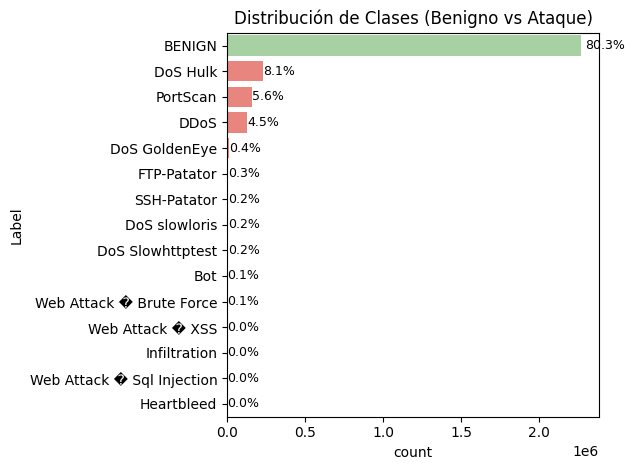

In [36]:
# Gráfico de la distribución de clases
counts = df['Label'].value_counts()
pcts = df['Label'].value_counts(normalize=True) * 100
colors = [COLOR_BENIGNO if c == 'BENIGN' else COLOR_ATAQUE for c in counts.index]

# Gráfico horizontal ordenado (mayor a menor)
ax = sns.countplot(y='Label', data=df, order=counts.index, palette=colors)

# Añadir porcentaje al final de cada barra
for i, (label, count, pct) in enumerate(zip(counts.index, counts.values, pcts.values)):
    ax.text(count + (count * 0.01), i, f'{pct:.1f}%',
            va='center', ha='left', fontsize=9)

plt.title('Distribución de Clases (Benigno vs Ataque)')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_distribucion_clases.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Preguntas

**¿Cuál es la variable objetivo?**
La variable objetivo es Label, que indica si el tráfico es benigno o un tipo de ataque.

**¿Hay múltiples clases o solo binario?**
Hay múltiples clases (multiclase), incluyendo distintos tipos de ataques.

**¿Qué variables parecen derivadas?**
Muchas variables representan métricas de red, por ejemplo: Flow Duration, Total Fwd Packets, Flow Bytes/s y Flow Packets/s, estas son creadas a partir del tráfico.

**¿Está balanceado el dataset?**
El dataset está desbalanceado, ya que la clase BENIGN representa el 80% de los datos.

**¿Qué ataques dominan?**
Los 3 ataques más frecuentes son: DoS Hulk, PortScan y DDoS. Mientras que Heartbleed, Web Attack-Sql Injection	o Infiltration son extremadamente raros.


## 2.3 Estadísticas descriptivas

### 2.3.1 Estadísticos completos: media, std, min, cuartiles, max

In [8]:
# Desactivar notación científica y mostrar números normales
pd.set_option('display.float_format', '{:.2f}'.format)

# Calcular estadísticos base
desc = df[num_cols].describe().T

# Agregar columnas extra útiles para el análisis
desc['median']    = df[num_cols].median()              # mediana
desc['skewness']  = df[num_cols].skew()                # sesgo
desc['kurtosis']  = df[num_cols].kurtosis()            # curtosis
desc['%_zeros']   = (df[num_cols] == 0).mean() * 100   # % de ceros
desc['%_nan']     = df[num_cols].isnull().mean() * 100 # % de NaN

# Ordenar por sesgo descendente para ver las más problemáticas primero
desc_sorted = desc.sort_values('skewness', ascending=False)

print(desc_sorted[['count', 'mean', 'median', 'std', 'min', '25%',
                    '75%', 'max', 'skewness', 'kurtosis',
                    '%_zeros', '%_nan']].to_string())

                                 count        mean   median         std             min    25%        75%          max  skewness   kurtosis  %_zeros  %_nan
Total Length of Fwd Packets 2830743.00      549.30    62.00     9993.59            0.00  12.00     187.00  12900000.00    805.57  988552.62    15.87   0.00
Subflow Fwd Bytes           2830743.00      549.29    62.00     9980.07            0.00  12.00     187.00  12870338.00    803.60  984882.53    15.87   0.00
act_data_pkt_fwd            2830743.00        5.42     1.00      636.43            0.00   0.00       2.00    213557.00    284.60   83076.67    34.02   0.00
Total Backward Packets      2830743.00       10.39     2.00      997.39            0.00   1.00       4.00    291922.00    244.68   62017.98    16.02   0.00
Subflow Bwd Packets         2830743.00       10.39     2.00      997.39            0.00   1.00       4.00    291922.00    244.68   62017.98    16.02   0.00
Subflow Fwd Packets         2830743.00        9.36     2.00     

In [12]:
# Guardar la tabla descriptiva como CSV para consultarla
desc_sorted.to_csv(f'{CHECKPOINT_DIR}/estadisticos_descriptivos.csv')
print('Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv')

Tabla guardada en: Checkpoints/estadisticos_descriptivos.csv


### 2.3.2 Valores infinitos

In [13]:
# Ver valores infinitos por columna
inf_por_columna = np.isinf(df[num_cols]).sum()
print(inf_por_columna[inf_por_columna > 0])

Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [14]:
#Reemplazar loa valores infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

### 2.3.3 Valores faltantes (NaN)

In [15]:
# Valores faltantes (solo los que son > 0)
df.isnull().sum()[df.isnull().sum() > 0]

,0
Flow Bytes/s,2867
Flow Packets/s,2867


In [19]:
# Alicar descisión
filas_antes = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)
print(f'Filas eliminadas: {filas_antes - filas_despues:,}')
print(f'Dataset final: {filas_despues:,} filas')

# Verificación
nan_total_final = df.isnull().sum().sum()
print(f'NaN restantes: {nan_total_final}')


Filas eliminadas: 2,867
Dataset final: 2,827,876 filas
NaN restantes: 0


### Preguntas

**¿Cómo se distribuyen las variables?**
Las variables presentan alta dispersión, distribuciones sesgadas (no normales) y valores extremos en varias columnas.

**¿Hay valores raros?**
Sí, existen valores infinitos (np.inf) en variables como: Flow Bytes/s y Flow Packets/s.
Estos deben tratarse antes de modelar.


**¿Hay valores faltantes?** Sí, existen valores faltantes de la variable Flow Bytes/s y Flow Packets/s.

**DECISIÓN: ¿Eliminamos o Imputamos estos valores faltantes?** Tenemos 5,734 valores de NaN, solo son 2867 filas (0.1% del dataset), eliminarlas no sesga el entrenamiento.



### 2.3.4 Análisis de Outliers

In [20]:
# Análisis de outliers
Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contar outliers por columna
outliers_count = (
    (df[num_cols] < limite_inferior) | (df[num_cols] > limite_superior)
).sum()

outliers_pct = (outliers_count / len(df) * 100).round(2)

outliers_df = pd.DataFrame({
    'n_outliers': outliers_count,
    'pct_outliers': outliers_pct
}).sort_values('pct_outliers', ascending=False)

# Top 20
print(outliers_df.head(20).to_string())
print(f'Features con > 10% de outliers: {(outliers_pct > 10).sum()}')
print(f'Features con > 20% de outliers: {(outliers_pct > 20).sum()}')

                             n_outliers  pct_outliers
Fwd IAT Mean                     670680         23.72
Fwd IAT Max                      665495         23.53
Fwd IAT Total                    665187         23.52
Fwd Packet Length Max            664211         23.49
Fwd Packet Length Std            663957         23.48
Fwd IAT Std                      659997         23.34
Bwd Packet Length Std            653968         23.13
Packet Length Variance           654086         23.13
Bwd Packet Length Max            637019         22.53
Destination Port                 625966         22.14
Max Packet Length                623427         22.05
Subflow Bwd Bytes                619005         21.89
Total Length of Bwd Packets      619005         21.89
Bwd IAT Std                      598847         21.18
Flow IAT Std                     598096         21.15
Flow IAT Mean                    572650         20.25
Bwd IAT Max                      567858         20.08
Idle Max                    

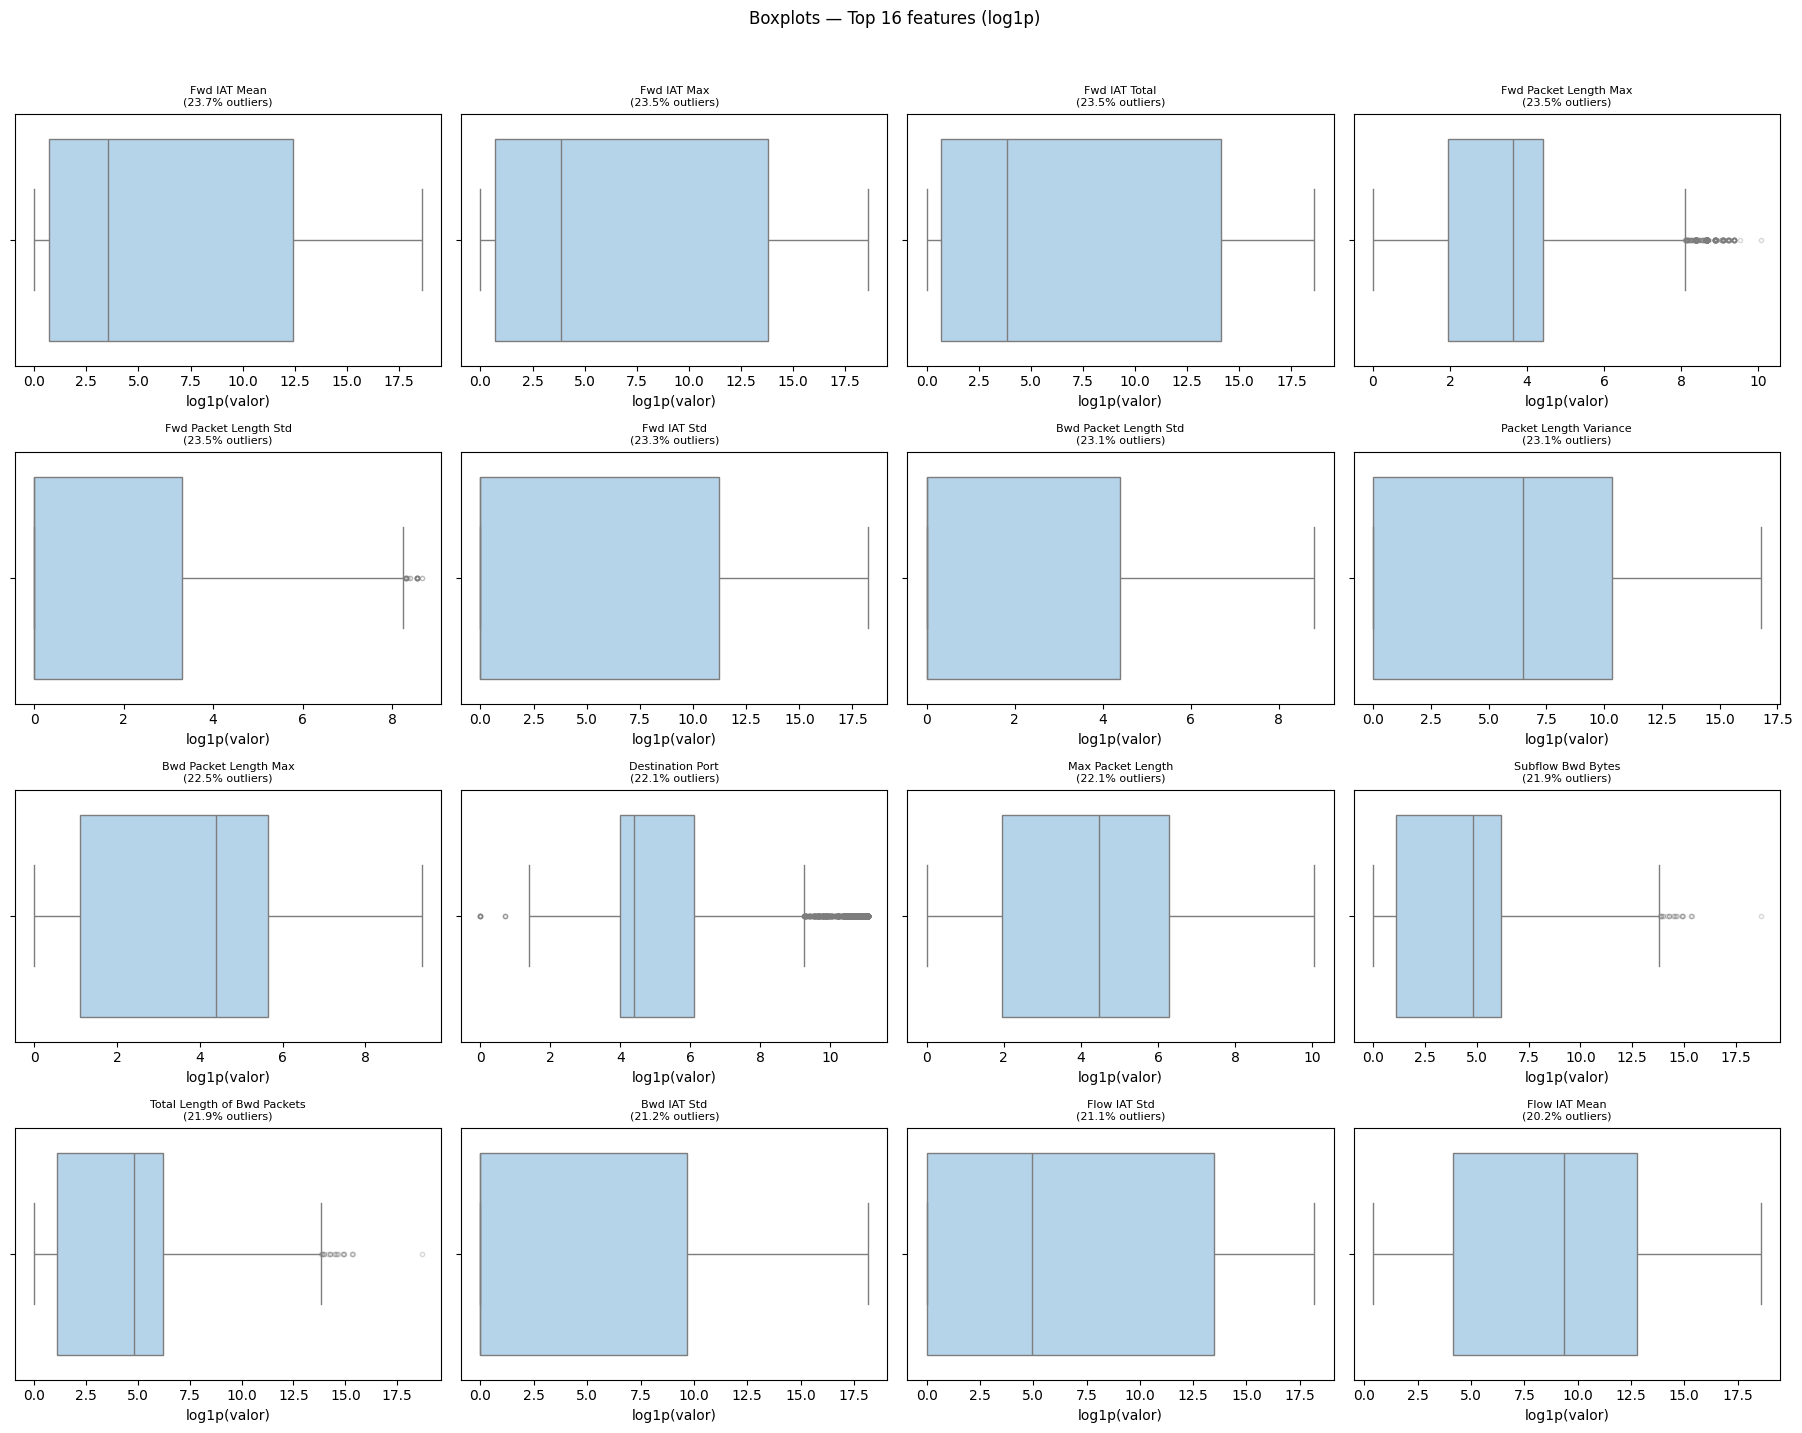

In [31]:
# Visualizamos las 16 con mayor proporción de outliers

# Preparación compacta de datos
cols = outliers_df.head(16).index.tolist()
muestra = df[num_cols].sample(min(30000, len(df)), random_state=42).apply(np.log1p)

# Configuración del gráfico con Seaborn
plt.figure(figsize=(18, 14))
for i, col in enumerate(cols):
    ax = plt.subplot(4, 4, i + 1)
    sns.boxplot(data=muestra[col], orient='h', color=COLOR_NEUTRO,
                flierprops={'marker': '.', 'alpha': 0.3})

    ax.set_title(f"{col}\n({outliers_pct[col]:.1f}% outliers)", fontsize=8)
    ax.set(xlabel='log1p(valor)')

plt.suptitle('Boxplots — Top 16 features (log1p)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/grafico_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Limpieza y Calidad del Dataset

## 3.1 Análisis de variables con comportamiento anómalo

In [33]:
# Features con rango cero (constantes)
# Si min == max la feature no aporta información al modelo
rango = df[num_cols].max() - df[num_cols].min()
constantes = rango[rango == 0].index.tolist()

print('FEATURES CONSTANTES')
if constantes:
    for col in constantes:
        print(f'  {col}: valor único = {df[col].unique()[0]}')
else:
    print('Ninguna feature tiene rango cero.')

FEATURES CONSTANTES
  Bwd PSH Flags: valor único = 0
  Bwd URG Flags: valor único = 0
  Fwd Avg Bytes/Bulk: valor único = 0
  Fwd Avg Packets/Bulk: valor único = 0
  Fwd Avg Bulk Rate: valor único = 0
  Bwd Avg Bytes/Bulk: valor único = 0
  Bwd Avg Packets/Bulk: valor único = 0
  Bwd Avg Bulk Rate: valor único = 0


In [34]:
# Features con alta proporción de ceros
pct_ceros = (df[num_cols] == 0).mean() * 100
pct_ceros_sorted = pct_ceros.sort_values(ascending=False)

# Mostrar las que tienen >50% de ceros
muchos_ceros = pct_ceros_sorted[pct_ceros_sorted > 50]

print(f'Features con más del 50% de valores en cero: {len(muchos_ceros)}')
print(muchos_ceros.to_string())

Features con más del 50% de valores en cero: 31
Bwd Avg Bulk Rate       100.00
Bwd Avg Packets/Bulk    100.00
Fwd Avg Bytes/Bulk      100.00
Fwd Avg Packets/Bulk    100.00
Bwd PSH Flags           100.00
Bwd URG Flags           100.00
Fwd Avg Bulk Rate       100.00
Bwd Avg Bytes/Bulk      100.00
CWE Flag Count           99.99
Fwd URG Flags            99.99
RST Flag Count           99.98
ECE Flag Count           99.98
FIN Flag Count           96.47
SYN Flag Count           95.36
Fwd PSH Flags            95.36
Active Std               92.73
Idle Std                 91.89
URG Flag Count           90.52
Active Min               80.24
Active Max               80.24
Active Mean              80.24
Idle Min                 79.94
Idle Mean                79.94
Idle Max                 79.94
Bwd Packet Length Std    71.56
Bwd IAT Std              71.30
PSH Flag Count           70.17
ACK Flag Count           68.47
Fwd Packet Length Std    65.35
Fwd IAT Std              62.71
Bwd Packet Length Min 

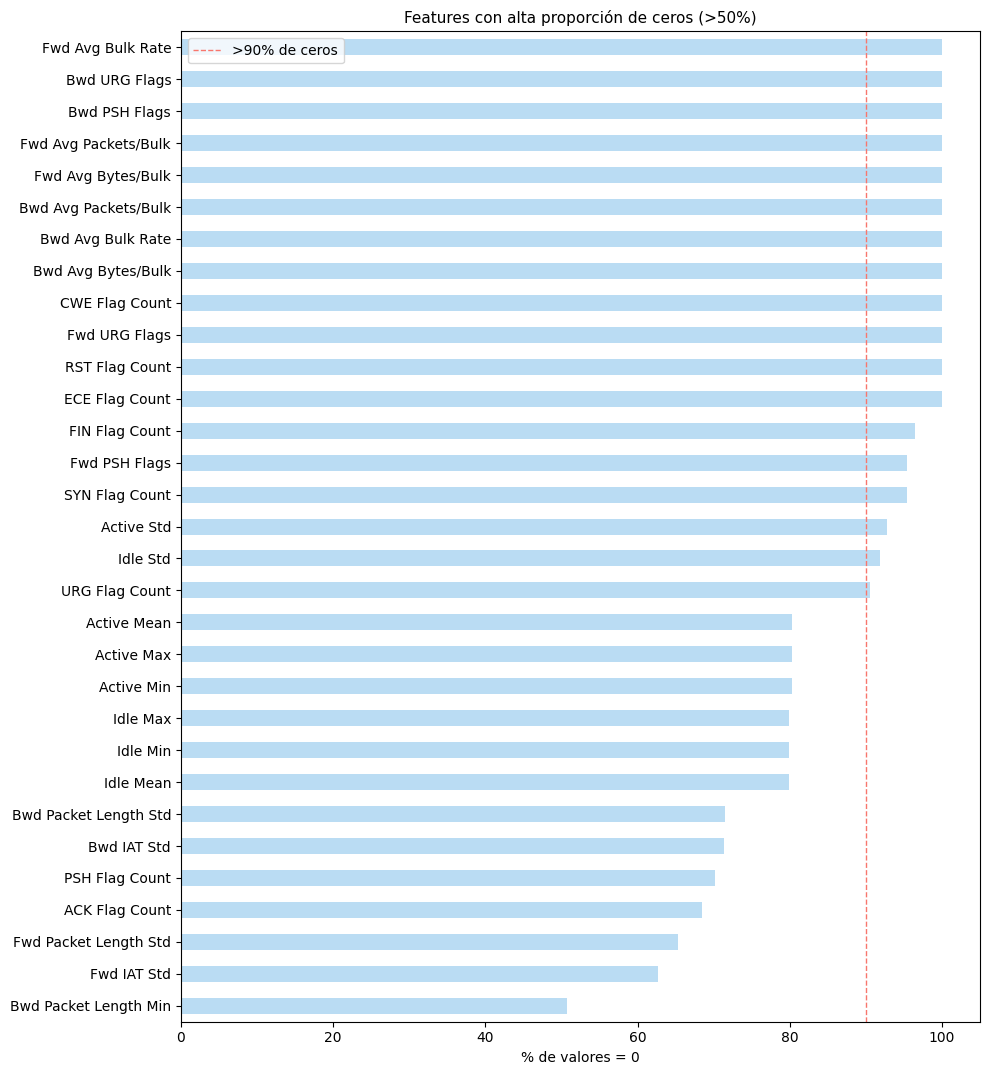

In [35]:
# Visualización
if not muchos_ceros.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(muchos_ceros) * 0.35)))
    muchos_ceros.sort_values().plot(
        kind='barh', ax=ax, color=COLOR_NEUTRO, alpha=0.85
    )
    ax.axvline(x=90, color=COLOR_ATAQUE, linestyle='--',
               linewidth=1, label='>90% de ceros')
    ax.set_xlabel('% de valores = 0')
    ax.set_title('Features con alta proporción de ceros (>50%)', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/grafico_features_con_ceros.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [38]:
# Features con valores negativos inesperados
# En tráfico de red, la mayoría de features deben ser >= 0 (bytes, paquetes, duración nunca son negativos)

negativos = {}
for col in num_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        negativos[col] = {'n_negativos': n_neg,
                          'valor_min': df[col].min()}

print('FEATURES CON VALORES NEGATIVOS')
if negativos:
    df_neg = pd.DataFrame(negativos).T
    print(df_neg.to_string())
    print('Verificar si son errores de medición.')
else:
    print('Ninguna feature tiene valores negativos.')

FEATURES CON VALORES NEGATIVOS
                         n_negativos       valor_min
Flow Duration                 115.00          -13.00
Flow Bytes/s                   85.00   -261000000.00
Flow Packets/s                115.00     -2000000.00
Flow IAT Mean                 115.00          -13.00
Flow IAT Max                  115.00          -13.00
Flow IAT Min                 2890.00          -14.00
Fwd IAT Min                    17.00          -12.00
Fwd Header Length              35.00 -32212234632.00
Bwd Header Length              22.00  -1073741320.00
Fwd Header Length.1            35.00 -32212234632.00
Init_Win_bytes_forward    1001172.00           -1.00
Init_Win_bytes_backward   1439672.00           -1.00
min_seg_size_forward           35.00   -536870661.00
Verificar si son errores de medición.


In [39]:
# Pares de Features idénticas (mismos valores en todas las filas)
# Comparamos hash del contenido de cada columna para detectar duplicados exactos

print('PARES DE FEATURES POTENCIALMENTE IDÉNTICAS')
hashes_cols = {}
for col in num_cols:
    h = hash(df[col].values.tobytes())
    if h in hashes_cols:
        print(f'  Columnas idénticas: "{hashes_cols[h]}" == "{col}"')
    else:
        hashes_cols[h] = col
print()
print('Búsqueda completada. Si no aparece ningún par, no hay columnas con valores exactamente iguales.')

PARES DE FEATURES POTENCIALMENTE IDÉNTICAS
  Columnas idénticas: "Bwd PSH Flags" == "Bwd URG Flags"
  Columnas idénticas: "Fwd PSH Flags" == "SYN Flag Count"
  Columnas idénticas: "Fwd URG Flags" == "CWE Flag Count"
  Columnas idénticas: "Fwd Header Length" == "Fwd Header Length.1"
  Columnas idénticas: "Bwd PSH Flags" == "Fwd Avg Bytes/Bulk"
  Columnas idénticas: "Bwd PSH Flags" == "Fwd Avg Packets/Bulk"
  Columnas idénticas: "Bwd PSH Flags" == "Fwd Avg Bulk Rate"
  Columnas idénticas: "Bwd PSH Flags" == "Bwd Avg Bytes/Bulk"
  Columnas idénticas: "Bwd PSH Flags" == "Bwd Avg Packets/Bulk"
  Columnas idénticas: "Bwd PSH Flags" == "Bwd Avg Bulk Rate"
  Columnas idénticas: "Total Fwd Packets" == "Subflow Fwd Packets"
  Columnas idénticas: "Total Backward Packets" == "Subflow Bwd Packets"

Búsqueda completada. Si no aparece ningún par, no hay columnas con valores exactamente iguales.


**Conclusiones del Análisis**

Tenemos los siguientes problemas críticos que afectan la calidad de los datos para el entrenamiento de un modelo:

* **Redundancia Absoluta (Varianza Cero)**: Existen 8 columnas constantes (como Bwd PSH Flags y Fwd Avg Bulk Rate) que contienen el mismo valor ($0$) en todas las filas.  
* **Altísima Proporción de Ceros**: Existen 31 variables donde más del 50% de los datos son ceros, llegando incluso al 100% en varios casos.
* **Inconsistencias Físicas (Valores Negativos)**: Existen valores negativos en variables donde no debería, como Flow Duration (duración), Flow Bytes/s y Header Length, esto sugiere errores de medición.  
* **Duplicidad de Información**: Existen varias columnas idénticas entre sí, como Fwd PSH Flags y SYN Flag Count, o las versiones duplicadas de Fwd Header Length.

**DECISIÓN**: Realizar una limpieza de columnas.

1. Eliminar Columnas Constantes
2. Columnas Duplicadas: vamos a quedarnos con una sola versión de los pares idénticos.
3. Variables con Valores Negativos Críticos:
    * Si los valores negativos son pocos, eliminarmos solo esas filas o reemplazarlos por el valor absoluto/mediana.
    * Si una columna tiene valores negativos muy extremos (como Fwd Header Length con $-32,212,234,632.00$), es mejor descartar la columna, ya que el dato es erroneo.

## 3.2 Limpieza y Calidad del Dataset

In [40]:
# Definir columnas a eliminar por categorías
cols_constantes = constantes  # Las 8 identificadas con rango cero
cols_duplicadas = [
    'Fwd Header Length.1',
    'Subflow Fwd Packets',
    'Subflow Bwd Packets',
    'SYN Flag Count',
    'CWE Flag Count'
]
# Eliminamos las que tienen errores de medición graves
cols_corruptas = ['Fwd Header Length', 'Bwd Header Length']

# Consolidar lista total de eliminación (sin duplicar nombres)
to_drop = list(set(cols_constantes + cols_duplicadas + cols_corruptas))

# Ejecutar la eliminación
df_clean = df.drop(columns=to_drop)

# Reporte de cambios
print(f"Limpieza completada.")
print(f"  - Columnas originales: {df.shape[1]}")
print(f"  - Columnas eliminadas: {len(to_drop)}")
print(f"  - Columnas restantes:  {df_clean.shape[1]}")
print(f"\nVariables eliminadas: {sorted(to_drop)}")

# Actualizar num_cols para futuros análisis
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

Limpieza completada.
  - Columnas originales: 79
  - Columnas eliminadas: 15
  - Columnas restantes:  64

Variables eliminadas: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Header Length', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length', 'Fwd Header Length.1', 'SYN Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Packets']


In [42]:
# CHECKPOINT: DATASET LIMPIO Y METADATOS
ruta_parquet = f'{CHECKPOINT_DIR}/dataset_checkpoint_sec3.parquet'
ruta_meta = f'{CHECKPOINT_DIR}/metadatos_limpieza.txt'

# Guardar Dataset
df_clean.to_parquet(ruta_parquet, index=False)

# Guardar Metadatos de la sesión
with open(ruta_meta, 'w') as f:
    f.write(f"Fecha: {datetime.datetime.now()}\n")
    f.write(f"Columnas finales: {df_clean.shape[1]}\n")
    f.write(f"Filas finales: {df_clean.shape[0]:,}\n")
    f.write(f"Variables eliminadas: {len(to_drop)}\n")
    f.write(f"Target balance (BENIGN %): {(df_clean['Label'] == 'BENIGN').mean()*100:.2f}%")

# Verificación
df_verify = pd.read_parquet(ruta_parquet)
print(f'Dataset guardado: {ruta_parquet}')
print(f'   Dimensiones    : {df_verify.shape[0]:,} filas × {df_verify.shape[1]} columnas')
print(f'   Tamaño disco   : {os.path.getsize(ruta_parquet) / 1024**2:.1f} MB')
print(f'   Metadatos en   : {ruta_meta}')

Dataset guardado: /content/drive/MyDrive/Colab Notebooks/Checkpoints/dataset_checkpoint_sec3.parquet
   Dimensiones    : 2,827,876 filas × 64 columnas
   Tamaño disco   : 308.7 MB
   Metadatos en   : /content/drive/MyDrive/Colab Notebooks/Checkpoints/metadatos_limpieza.txt
